# The code generates peaked quantum circuit

Here I follow the approach discussed in the paper ArXiv... to create a quasi-random peaked circuit with a hidden string.

- Initially, I create a random brick wall circuit. Let's call it M_0. Each brick is a 2 qubit block with 6 U gates and 2 CZ gate placed in a symmetric order. Angles for U gates are chosen in a random way.
- Then I create a "mirror" of that circuit (inverted, M_0^{-1}) and add it to the M_0. So, we get the circuit with performs identuty gate for all qubits
- Then the mirror part of the circuit is modified. At first the blocks in the mirror part are replaced by blocks with similar matrix but very different angles. Then double U gates are merged together. This break the mirror symmetry of the circuit and allows to hide the bitstring.
- Then the bitsring is added. X gates are initially applied at the beginning of the circut and then randomly moved to some distant place in the circuit using commutation relations.

### Import libraries

In [2]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex
from IPython.display import display

import numpy as np
import random
import copy
import time

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

### Definig functions that create a single brick in the brick wall ciruit, create peaked circuits etc

In [9]:
#Creates a single "brick" block and add it to an existing circuit
def add_double_cz_block(qc, params, qubits_list):
    qc.u(params[0], params[1], params[2], qubits_list[0])
    qc.u(params[3], params[4], params[5], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[6], params[7], params[8], qubits_list[0])
    qc.u(params[9], params[10], params[11], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(params[12], params[13], params[14], qubits_list[0])
    qc.u(params[15], params[16], params[17], qubits_list[1])
    return qc
#Creates a single inverted "brick" block and add it to an existing circuit
def add_double_inverse_cz_block(qc, params, qubits_list):
    pp = params
    qc.u(-pp[12], -pp[14], -pp[13], qubits_list[0])
    qc.u(-pp[15], -pp[17], -pp[16], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[6], -pp[8], -pp[7], qubits_list[0])
    qc.u(-pp[9], -pp[11], -pp[10], qubits_list[1])
    qc.cz(qubits_list[0], qubits_list[1])
    qc.u(-pp[0], -pp[2], -pp[1], qubits_list[0])
    qc.u(-pp[3], -pp[5], -pp[4], qubits_list[1])
    return qc
#Creates a single "brick" block operator
def double_cz_op(par):
    q_2 = qiskit.QuantumCircuit(2)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.cz(0,1)
    q_2.u(par[6], par[7], par[8], 0)
    q_2.u(par[9], par[10], par[11], 1)
    q_2.cz(0,1)
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    op = Operator(q_2)
    return op.data
#Calculate difference between two "brick" blocks
def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    return np.linalg.norm(mm)

cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}
# auxialiry function for optimization
def estim_func(params, params_init):
    init_circ = double_cz_op(params_init)
    test_circ = double_cz_op(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    
    return est
#Take an intial "brick" block and find another "brick" block that performs alsmost the same function as initial block
def find_alt_params(param_init, ftol):
    find = 0
    for i_try in range(10):
        param_0 = []
        for i in range(18):
            param_0.append(random.random() * 2 * PI)
    
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        
        res = minimize(
                    estim_func,
                    param_0,
                    args = (param_init),
                    method = 'cobyla', 
                    options = {"maxiter":  5000} 
                )
        #if res.success == 'True':
        if res.fun < ftol:
            break
    #print(i_try)
    return res

### Create peaked circuit

In [10]:
# Here we create a number of peaked circuit
# The list of number of qubits and circuit depth is defined below
# The hidden bitstring is defined in Part 3 of this section
#Positions of X gates in the circuit are also defined there
prep_time = []
rel_block_dev = []
rel_dev_from_peak = []

n_qubits_list = [8]#list of number of qubits for different cases
qc_depth_list = [8] #list of circuit depths for different cases
ftol_list = [0.06] #desired precision in block replacement for different cases
n_try_av = 1 #number of tries to create an initial peaked circuit without hidden string. Needed if you want to get average circuit preparation time. 
#Otherwise set to 1

number_of_tries = 1

mean_block_deviation = np.zeros(len(n_qubits_list)) #average block deviation 
relative_peakness = np.zeros(len(n_qubits_list)) #peakedness of the circuit

for i_case in range(1): #here we go over all cases (all number of qubits and circuit depths and tolearnces)
    #print(f"CASE NUMBER: {i_case}")
    print(f"number of qubits: {n_qubits_list[i_case]}")
    print(f"QC depth: {qc_depth_list[i_case]}")
    mbd = 0
    rel_peak = 0
    for i_try_av in range(n_try_av): #We try to create an initial circuit multiple time. This is just to measure average ciruit preparation time.
        #Part 1
        #here I do several tries to build the random peaked circuit with '000..00' peaked state
        #I do several tries to get averaged creation time and average error
        mean_elapsed_time = 0
        mean_block_dev = 0
        for i_try in range(number_of_tries):
            start_time = time.time()
            n_qubits = n_qubits_list[i_case] #should be even
            qc_depth = qc_depth_list[i_case] #this is circuit half-depth
            ftol = ftol_list[i_case]
            
            n_randon_blocks = int(n_qubits / 2 * qc_depth) #number of random blocks for the first half of the circuit
            
            q_reg = Q_R(n_qubits)
            c_reg = C_R(n_qubits)
            qc_rand = qiskit.QuantumCircuit(q_reg, c_reg)
            
            #Get angles for all blocks in the fisrt half of the circuit
            params = []
            for i in range(n_randon_blocks):
                pp = []
                for j in range(18):
                    pp.append(random.random() * 2 * PI)
                params.append(pp)
            #Get pairs of qubits for all blocks
            block_n = 0
            qubits_pairs_order = []
            for i in range(qc_depth):
                if i % 2 == 0:
                    for i_q in range(int(n_qubits / 2)):
                        qubits_pairs_order.append([i_q * 2, i_q * 2 + 1])
                        block_n = block_n + 1
                if i % 2 == 1:
                    qubits_pairs_order.append([0, n_qubits - 1])
                    block_n = block_n + 1
                    for i_q in range(int(n_qubits / 2) - 1):
                        qubits_pairs_order.append([i_q * 2 + 1, i_q * 2 + 2])
                        block_n = block_n + 1
            #Create first random part of the circuit
            for i_block in range(block_n):
                qc_rand = add_double_cz_block(qc_rand, params[i_block], qubits_pairs_order[i_block])

            #Create the mirror part of the circuit. Each block in the mirror part is replaced by a similar one but with different angles
            block_dev = []
            for i_block in range(block_n):
                param_init = params[n_randon_blocks - 1 - i_block] #mirror block parameter
                res_min = find_alt_params(param_init, ftol) #Find alternative angles giving similar block
                new_params = res_min.x
                block_dev.append(res_min.fun)
                qc_rand = add_double_inverse_cz_block(qc_rand, new_params, qubits_pairs_order[n_randon_blocks - 1 - i_block])# put alternatuve block instead
            
            for i in range(n_qubits):
                qc_rand.measure(i,i)
            #print(np.mean(block_dev))

            #Calculate average deviation of block in the mirror portion of the circuit. It defines how peaked the cirucit is
            mean_block_dev = mean_block_dev + np.mean(block_dev)
            end_time = time.time()
            elapsed_time = end_time - start_time
        
            mean_elapsed_time = mean_elapsed_time + elapsed_time
            #print(f"Number of blocks modified:  {n_randon_blocks}")
            #print(f"Elapsed time: {elapsed_time} seconds")
        
        print(f"Mean elapsed time: {mean_elapsed_time}")
        #print(f"Mean block dev: {mean_block_dev}")
        mbd = mbd + mean_block_dev
    
        #Part 2
        #here I take the last random circuit and merge all double U-gates into single U gate
        #merging the double U gates
        circuit_len = len(qc_rand.data)
        instructions = []
        for instruction, qargs, cargs in qc_rand:
            instructions.append((instruction, qargs, cargs))

        delete_list = []
        modify_list = []
        params_list = []
        for i_q in range(n_qubits): #for each qubit we find double U gates and then merge then into a single U gate
            prev_gate = 0
            for i_inst in range(circuit_len):
                q_num = []
                q_num.append(instructions[i_inst][1][0]._index)
                qibits_in_gate = len(instructions[i_inst][1])
                if qibits_in_gate == 2:
                    q_num.append(instructions[i_inst][1][1]._index)
                gate_name = instructions[i_inst][0].name
                #print(q_num)
                if i_q in q_num:
                    if gate_name == 'cz':
                        prev_gate = 0
                    else:
                        if gate_name == 'u' and prev_gate == 0:
                            prev_gate = 1
                            last_u = i_inst
                        else:
                            if gate_name == 'u' and prev_gate == 1: #get parameters for the replacement of double U gates to single U gate, get the list of gates to be exculded and replaced
                                #print('found')
                                delete_list.append(last_u)
                                modify_list.append(i_inst)
                                qc_temp = qiskit.QuantumCircuit(1)
                                par = instructions[last_u][0].params
                                qc_temp.u(par[0], par[1], par[2], 0)
                                par = instructions[i_inst][0].params
                                qc_temp.u(par[0], par[1], par[2], 0)
                                qc_temp_tr = transpile(qc_temp, basis_gates = ['u3','cx'])
                                instruction_new = qc_temp_tr.data[0]
                                params = instruction_new[0].params
                                
                                params_list.append(params)
                                prev_gate = 0
                 
        #One of the double U gates is deleted and another one is modified so it replaces both
        mod_instr = []
        mod_instr = copy.deepcopy(instructions)
        for i_inst in range(len(modify_list)):
            mod_instr[modify_list[i_inst]][0].params = params_list[i_inst]
        for index in sorted(delete_list, reverse=True):
            mod_instr.pop(index)
        #New circuit is created with all double U gates replaced with a single U gates      
        qc_merged = qiskit.QuantumCircuit(n_qubits, n_qubits)
        for i_instr in range(len(mod_instr) - n_qubits):
            instruction = mod_instr[i_instr][0]
            qarg = mod_instr[i_instr][1] 
            if len(qarg) == 1:
                qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index], [])
            if len(qarg) == 2:
                qc_merged.append(instruction, [mod_instr[i_instr][1][0]._index, mod_instr[i_instr][1][1]._index], [])
                
        for i in range(n_qubits):
            qc_merged.measure(i,i) 
   
        #Part 3
        #here I convert '0000...00' peaked state to some predefined peaked state with ones and zeroes like '11010001..01'
        #I move x gates from the beginning of the circuit to some chosen position
        circuit_len = len(qc_merged.data)
        instructions_m = []
        for instruction, qargs, cargs in qc_merged:
            instructions_m.append((instruction, qargs, cargs))
        
        #Creating a "true" copy of the instructions set
        mod_instr_1 = []
        mod_instr_1 = copy.deepcopy(instructions_m)
                
        list_of_switched_qubits = [0, 1] #list of qubits to whose we apply X operator. This is a hidden bitstring
        list_of_shifts = [1, 3] #positions of the X gates. We move them from the beginning of the ciruit to the inside of the ciruit
        #Number here are number of block we move the X gate through
        
        for ii_q in range(len(list_of_switched_qubits)): #loop over all qubits which will be switched
            i_q = list_of_switched_qubits[ii_q]
            
            #Getting the lists of modified gates for given modfied qubit
            #When we move the X gate through the ciruit we use the commutation rule considered in the corresponding Jupyter Notebook
            if i_q == 0:
                involved_qubits = [n_qubits - 1, 1]
            else:
                if i_q == n_qubits - 1:
                    involved_qubits = [n_qubits - 2, 0]
                else: 
                    involved_qubits = [i_q - 1, i_q + 1]
            n_zcs_move = list_of_shifts[ii_q]
            list_of_neighbourong_U_above = []
            list_of_neighbourong_U_below = []
            check_neighbour_below = 0
            check_neighbour_above = 0
            list_of_U = []
            check_neighbour = 0
            curr_cz = 0
            check_neighbour_only = 0

            #Here we define which gate should be modified according to commutation rules
            for i_inst in range(circuit_len): 
                #get qubits participating in the gate
                q_num = []
                q_num.append(mod_instr_1[i_inst][1][0]._index)
                qibits_in_gate = len(mod_instr_1[i_inst][1])
                if qibits_in_gate == 2:
                    q_num.append(mod_instr_1[i_inst][1][1]._index)
                gate_name = mod_instr_1[i_inst][0].name
                match check_neighbour_only:
                    case 0:
                        if i_q in q_num:
                            if gate_name == 'u':
                                list_of_U.append(i_inst)
                            else:
                                if gate_name == 'cz' and curr_cz == n_zcs_move:
                                    if check_neighbour_above == 0 and check_neighbour_below == 0:
                                        break
                                    else:
                                        check_neighbour_only = 1
                                else:
                                    curr_cz = curr_cz + 1
                                    if involved_qubits[0] in q_num:
                                        check_neighbour_above = 1
                                    if involved_qubits[1] in q_num:
                                        check_neighbour_below = 1
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
            
                    case 1:
                        if involved_qubits[0] in q_num:
                            if check_neighbour_above == 1 and gate_name == 'u':
                                list_of_neighbourong_U_above.append(i_inst)
                                check_neighbour_above = 0
                        if involved_qubits[1] in q_num:
                            if check_neighbour_below == 1 and gate_name == 'u':
                                list_of_neighbourong_U_below.append(i_inst)
                                check_neighbour_below = 0
                        if check_neighbour_below == 0 and check_neighbour_above == 0:
                            break
            
            #modify instructions according to the list we get previously
            for i_inst in range(len(list_of_neighbourong_U_below)):
                params_new = mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params
                params_new_1 =[params_new[0], params_new[1], PI + params_new[2]] 
                mod_instr_1[list_of_neighbourong_U_below[i_inst]][0].params = params_new_1
            if n_qubits > 2:
                for i_inst in range(len(list_of_neighbourong_U_above)):
                    params_new = mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params
                    params_new_1 =[params_new[0], params_new[1], PI + params_new[2]]
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
                    mod_instr_1[list_of_neighbourong_U_above[i_inst]][0].params = params_new_1
                    #print( mod_instr_1[list_of_neighbourong_U_above[i_inst]])
            for i_inst in range(len(list_of_U) - 1):
                params_new = mod_instr_1[list_of_U[i_inst]][0].params
                params_new_1 =[params_new[0], PI - params_new[1], PI - params_new[2]] 
                mod_instr_1[list_of_U[i_inst]][0].params = params_new_1
            params_new = mod_instr_1[list_of_U[len(list_of_U) -1]][0].params
            params_new_1 =[PI - params_new[0], params_new[1] - PI, - params_new[2]]
            mod_instr_1[list_of_U[len(list_of_U) -1]][0].params = params_new_1
                
        #Creating a new quantm circuits with modifications   
        qc_merged_1 = qiskit.QuantumCircuit(n_qubits, n_qubits)
        for i_instr in range(len(mod_instr_1) - n_qubits):
            instruction = mod_instr_1[i_instr][0]
            qarg = mod_instr_1[i_instr][1] 
            if len(qarg) == 1:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index], [])
            if len(qarg) == 2:
                qc_merged_1.append(instruction, [mod_instr_1[i_instr][1][0]._index, mod_instr_1[i_instr][1][1]._index], [])
        
        for i in range(n_qubits):
            qc_merged_1.measure(i,i) 
    
        #Part 4
        #Here I perfrom quantum simulations of the circuits
        #Initial randm circuit
        simulator = AerSimulator()
        qc_merged_t = transpile(qc_rand, simulator)
        result = simulator.run(qc_merged_t,shots = 10000).result()
        counts = result.get_counts(qc_merged_t)
        #random circuit with mirror circuit modification, but without the hidden string
        qc_merged_t = transpile(qc_merged, simulator)
        result = simulator.run(qc_merged_t,shots = 10000).result()
        counts = result.get_counts(qc_merged_t)
        #random circuit with hidden string
        simulator = AerSimulator()
        qc_merged_t = transpile(qc_merged_1, simulator)
        result = simulator.run(qc_merged_t,shots = 10000).result()
        counts = result.get_counts(qc_merged_t)

        #Calculate peakedness of the circuit (probability to find any state beside the hiddent bitstring)
        rel_peak = rel_peak + (10000 - max(counts.values()))/10000
        print(f"Relative deviation from the peak: {(10000 - max(counts.values()))/10000}")
        print(f"\n")


    mbd = mbd / n_try_av
    mean_block_deviation[i_case] = mbd
    rel_peak = rel_peak / n_try_av
    relative_peakness[i_case] = rel_peak
    print(f"Mean block deviation: {mbd}")
    print(f"Mean relative deviation from the peak: {rel_peak}")


number of qubits: 8
QC depth: 8
Mean elapsed time: 149.87220406532288
Relative deviation from the peak: 0.0949


Mean block deviation: 0.05038769571719378
Mean relative deviation from the peak: 0.0949


In [15]:
#Showing top 10 bitsrings of the final state
top_10_MPS = sorted(counts.items(), key=lambda item: item[1], reverse=True)[:10]
for (k1, v1), (k2, v2) in zip(top_10_MPS, top_10_MPS):
                print(f"{k1} = {v1:<16} | {k2} = {v2}")

00000011 = 9051             | 00000011 = 9051
00110011 = 59               | 00110011 = 59
00001110 = 47               | 00001110 = 47
00000001 = 45               | 00000001 = 45
00000010 = 43               | 00000010 = 43
00000110 = 27               | 00000110 = 27
00011011 = 24               | 00011011 = 24
00001111 = 20               | 00001111 = 20
11000001 = 20               | 11000001 = 20
00101000 = 19               | 00101000 = 19


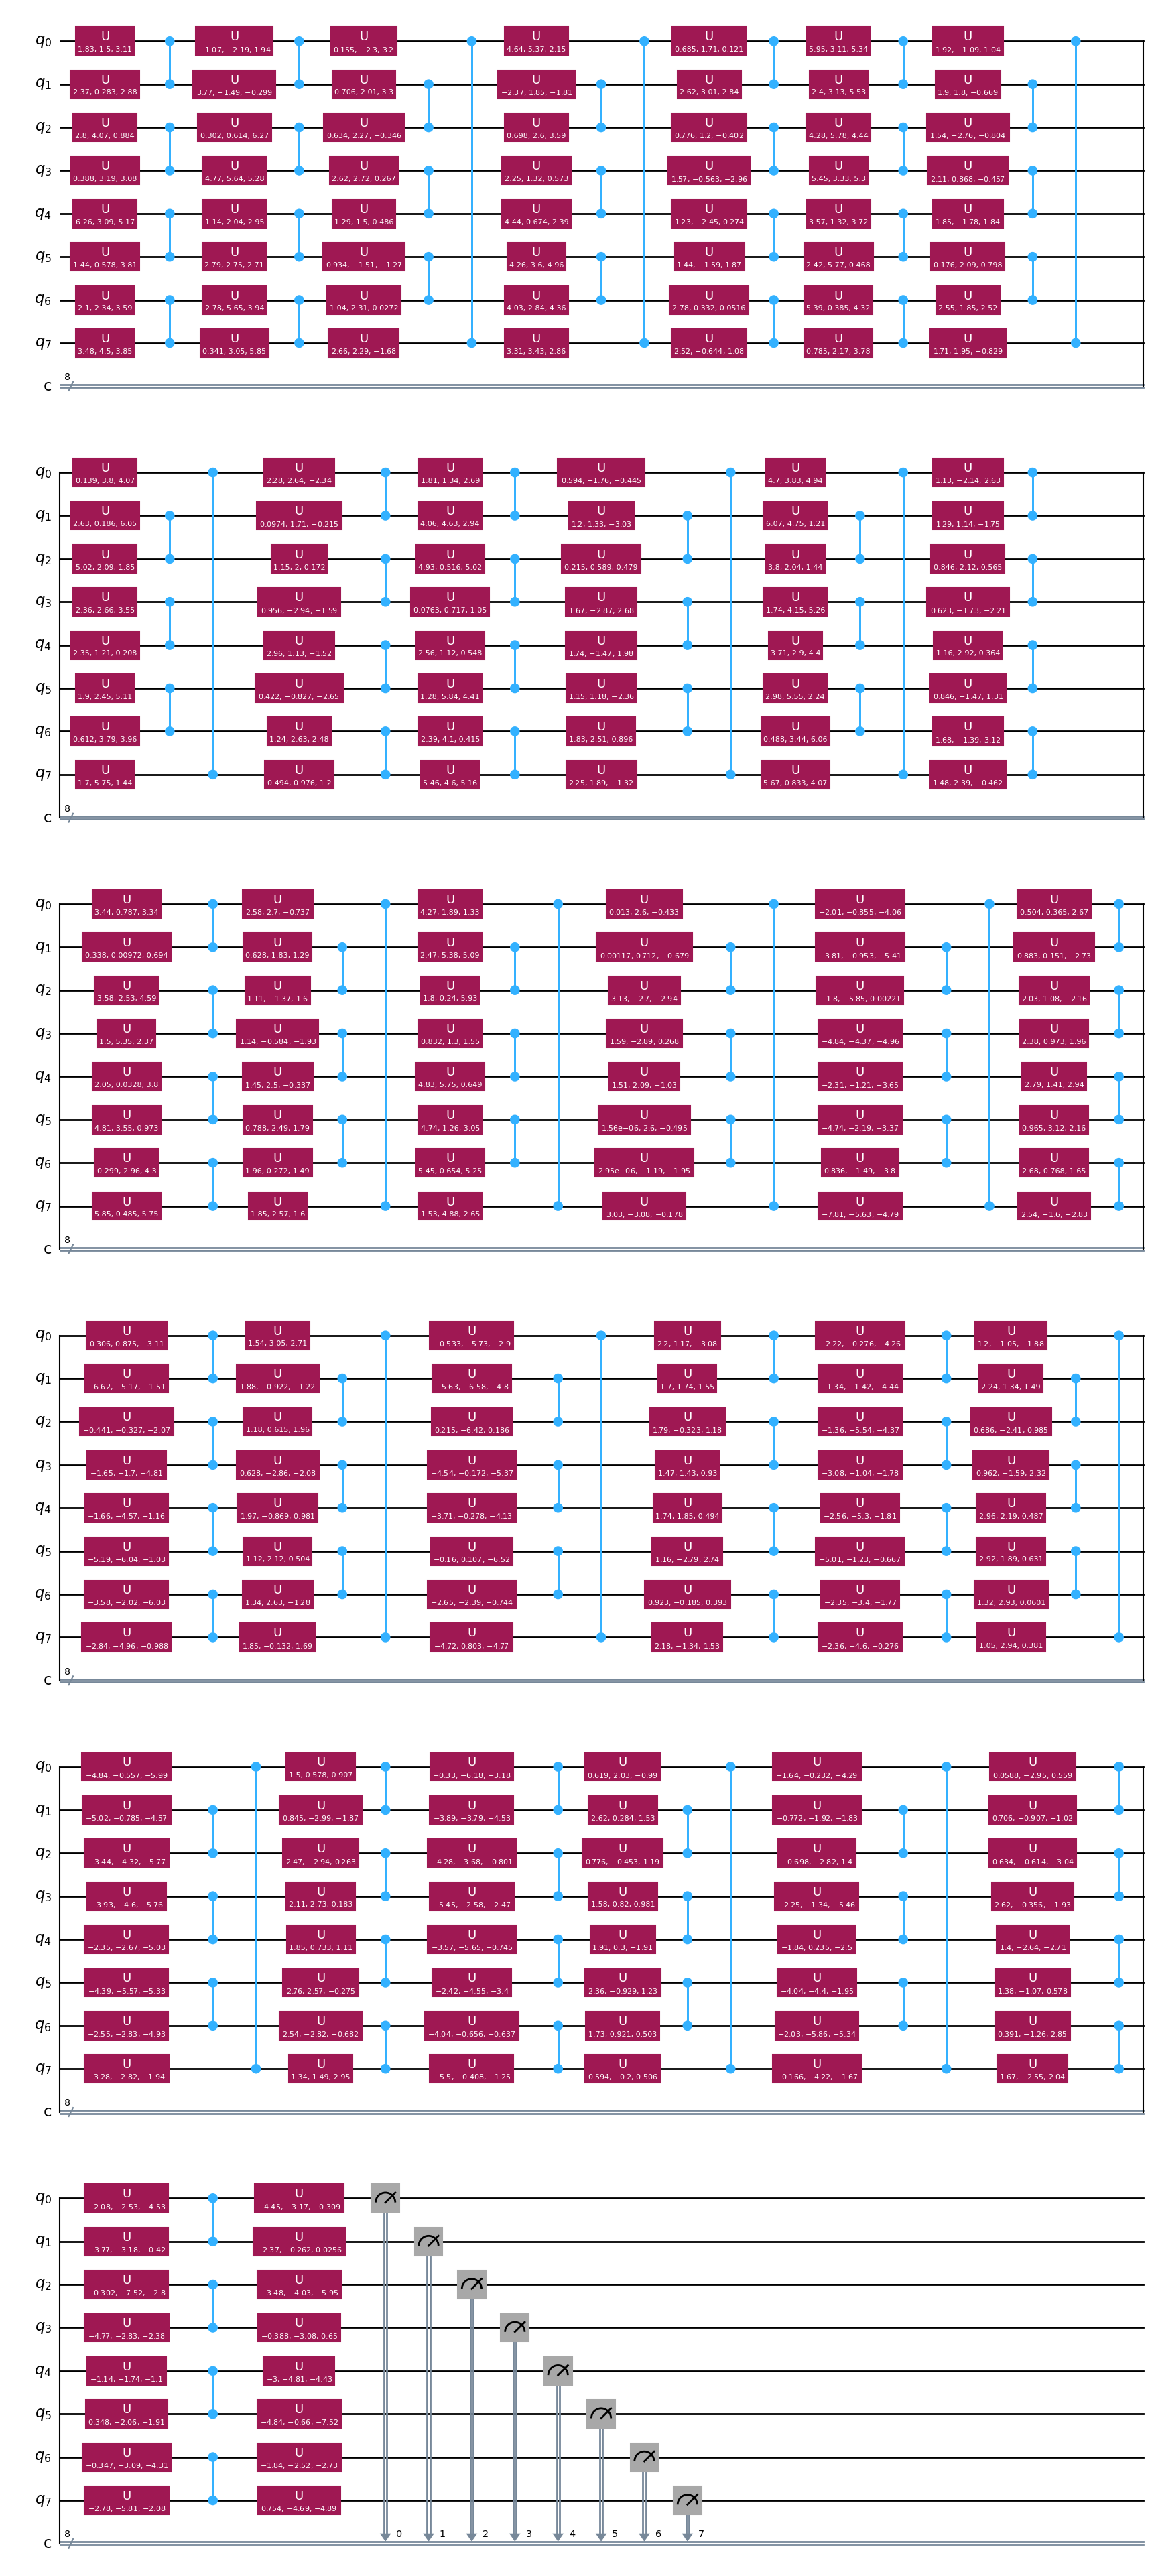

In [14]:
#Final quasi-random peaked circuit with hidden bitstring
qc_merged_t.draw('mpl')